# Used car market exploratory data analysis

This notebook explores the raw, Hatla2ee used car listings collected for a used car price prediction project. It describes the market and identifies data issues and potential predictive signals. No pre proccessing is done yet, we only want to explore the data

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'

def find_project_root(start: Path) -> Path:
    """Find the repository root without hard-coding a machine-specific path."""
    for candidate in (start, *start.parents):
        if (candidate / 'Data' / 'used_cars_cleaned.csv').is_file():
            return candidate
    raise FileNotFoundError(
        'Could not find Data/used_cars_cleaned.csv. Run this notebook from the project directory or its Notebooks subdirectory.'
    )

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_PATH = PROJECT_ROOT / 'Data' / 'used_cars_cleaned.csv'
print(f'Loading data from: {DATA_PATH}')

Loading data from: /Users/yassien/Documents/Uni/MachineLearning/Project/Data/used_cars_cleaned.csv


In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
display(df.head())

Dataset shape: 10,819 rows × 14 columns


,id,title,year,ad_date,transmission,price,fingerprint,fuel,brand,model,color,class,km,city
0,7222579,Cupra Terramar 2026,2026,NaN,1,1200000,7222579-1200000,Natural Gas,Cupra,Terramar,NaN,NaN,"2,000 KM","Nasr city, Cairo"
1,7204848,Seat Tarraco 2021,2021,NaN,1,1580000,7204848-1580000,Gas,Seat,Tarraco,NaN,NaN,"59,000 KM","Nasr city, Cairo"
2,7209848,Volkswagen Passat 2022,2022,NaN,1,1830000,7209848-1830000,Gas,Volkswagen,Passat,NaN,NaN,"60,000 KM","Nasr city, Cairo"
3,7223028,Audi Q3 2024,2024,NaN,1,2590000,7223028-2590000,Gas,Audi,Q3,NaN,NaN,"14,000 KM","Smouha, Alexandria"
4,7189822,Mercedes CLS Class 2019,2019,NaN,1,3650000,7189822-3650000,Gas,Mercedes,CLS Class,NaN,NaN,"63,000 KM","Nozha, Alexandria"


## Variables and intended roles


Table below describes the available data fields and which can be used for features, 
1.  `id` and `fingerprint` identify listings
2. `price` is the future prediction target
3. `ad_date`, `color`, and `class` are empty

In [ ]:
data_dictionary = pd.DataFrame([
    ('id', 'Identifier', 'Listing identifier; useful for uniqueness checks, not as a model feature.'),
    ('title', 'Potential feature', 'Original listing title; may overlap with brand, model, and year.'),
    ('year', 'Potential feature', 'Vehicle model year.'),
    ('ad_date', 'Unavailable', 'Scraper output is empty in this dataset.'),
    ('transmission', 'Potential feature', 'Scraper encoding: 1 = Automatic and 0 = Manual.'),
    ('price', 'Target', 'Advertised price in Egyptian pounds (EGP).'),
    ('fingerprint', 'Identifier', 'Listing-price fingerprint used during de-duplication.'),
    ('fuel', 'Potential feature', 'Fuel type from the listing.'),
    ('brand', 'Potential feature', 'Vehicle manufacturer.'),
    ('model', 'Potential feature', 'Vehicle model name.'),
    ('color', 'Unavailable', 'Scraper output is empty in this dataset.'),
    ('class', 'Unavailable', 'Scraper output is empty in this dataset.'),
    ('km', 'Potential feature', 'Mileage stored as text, for example, 120,000 KM.'),
    ('city', 'Potential feature', 'Listing location; values may include city and district.'),
], columns=['Column', 'Role', 'Description'])
display(data_dictionary)

,Column,Role,Description
0,id,Identifier,Listing identifier; useful for uniqueness chec...
1,title,Potential feature,Original listing title; may overlap with brand...
2,year,Potential feature,Vehicle model year.
3,ad_date,Unavailable,Scraper output is empty in this dataset.
4,transmission,Potential feature,Scraper encoding: 1 = Automatic and 0 = Manual.
5,price,Target,Advertised price in Egyptian pounds (EGP).
6,fingerprint,Identifier,Listing-price fingerprint used during de-dupli...
7,fuel,Potential feature,Fuel type from the listing.
8,brand,Potential feature,Vehicle manufacturer.
9,model,Potential feature,Vehicle model name.


## Dataset profile

The cleaned CSV has already removed exact duplicates and duplicate fingerprints. The checks below verify that result and show completeness and cardinality.

In [4]:
profile = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_values': df.isna().sum(),
    'missing_%': (df.isna().mean() * 100).round(1),
    'unique_values': df.nunique(dropna=True),
}).sort_values('missing_values', ascending=False)

duplicate_checks = pd.DataFrame({
    'Check': ['Exact duplicate rows', 'Duplicate listing IDs', 'Duplicate fingerprints'],
    'Count': [df.duplicated().sum(), df['id'].duplicated().sum(), df['fingerprint'].duplicated().sum()],
})

display(profile)
display(duplicate_checks)

,dtype,missing_values,missing_%,unique_values
ad_date,float64,10819,100.0,0
color,float64,10819,100.0,0
class,float64,10819,100.0,0
id,int64,0,0.0,10819
title,object,0,0.0,3538
year,int64,0,0.0,63
transmission,int64,0,0.0,2
price,int64,0,0.0,782
fingerprint,object,0,0.0,10819
fuel,object,0,0.0,6


,Check,Count
0,Exact duplicate rows,0
1,Duplicate listing IDs,0
2,Duplicate fingerprints,0


## Model-name uniqueness and city distribution

A model name by itself is not necessarily a unique car category: the same label can occur under different brands. The first table checks uniqueness both globally and at the more meaningful brand-plus-model level. The city table keeps every location value and orders it by listing count.

,Grouping,Distinct groups,Groups appearing once,Groups appearing more than once
0,Model name only,869,259,610
1,Brand + model,930,293,637


A model is unique only when its listing count is 1. The detailed brand-model counts below are sorted alphabetically by model, matching the requested check.


,brand,model,listing_count
922,Zeekr,001,4
762,Rox,01,1
23,Avatr,07,1
27,BMW,1 Series,1
24,Avatr,11,1
737,Renault,11,1
256,Fiat,1100,3
28,BMW,116,10
29,BMW,118,4
25,Avatr,12,5


Unique location values: 212


,city,listing_count
140,"Loran, Alexandria",1
52,"Bolkly, Alexandria",1
81,El Mansoura,1
28,"Alasafra, Alexandria",1
121,Honda City 2010,1
...,...,...
29,Alexandria,666
2,"6 October, Giza",748
162,"Nasr city, Cairo",911
201,"Tagamo3 - New Cairo, Cairo",1425


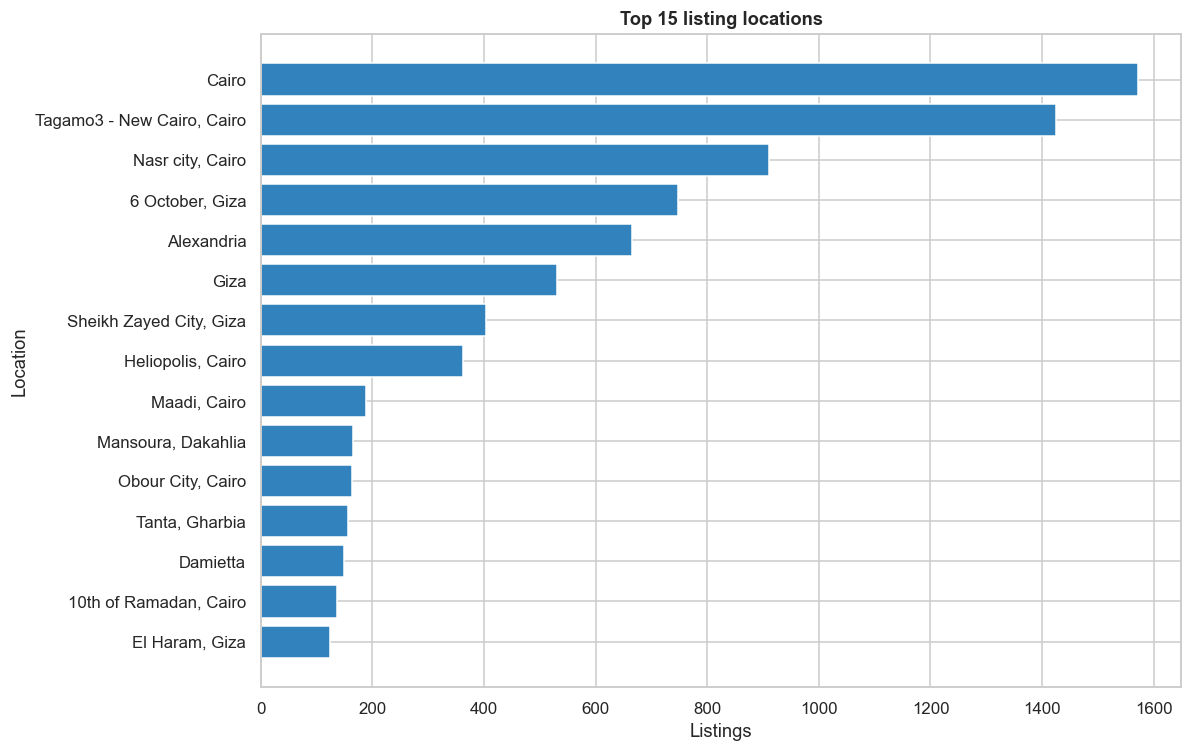

In [5]:
model_counts = (
    df.groupby('model', dropna=False)
    .size()
    .rename('listing_count')
    .sort_values(ascending=False)
)
brand_model_counts = (
    df.groupby(['brand', 'model'], dropna=False)
    .size()
    .rename('listing_count')
    .reset_index()
)

model_uniqueness_summary = pd.DataFrame({
    'Grouping': ['Model name only', 'Brand + model'],
    'Distinct groups': [model_counts.size, len(brand_model_counts)],
    'Groups appearing once': [(model_counts == 1).sum(), (brand_model_counts['listing_count'] == 1).sum()],
    'Groups appearing more than once': [(model_counts > 1).sum(), (brand_model_counts['listing_count'] > 1).sum()],
})
display(model_uniqueness_summary)

print('A model is unique only when its listing count is 1. The detailed brand-model counts below are sorted alphabetically by model, matching the requested check.')
display(brand_model_counts.sort_values(['model', 'brand']).head(20))

city_distribution = (
    df.groupby('city', dropna=False)
    .size()
    .rename('listing_count')
    .reset_index()
    .sort_values('listing_count', ascending=True)
)
print(f'Unique location values: {len(city_distribution):,}')
display(city_distribution)

top_cities = city_distribution.tail(15)
plt.figure(figsize=(11, 7))
plt.barh(top_cities['city'], top_cities['listing_count'], color='#3182bd')
plt.title('Top 15 listing locations')
plt.xlabel('Listings')
plt.ylabel('Location')
plt.tight_layout()
plt.show()

## Temporary EDA helper columns

`km_numeric`, `transmission_label`, and `fuel_display` make the raw fields readable for summaries and plots. 

In [6]:
df_eda = df.copy()
df_eda['km_numeric'] = pd.to_numeric(
    df_eda['km'].astype(str).str.replace(r'[^0-9]', '', regex=True),
    errors='coerce',
)
df_eda['transmission_label'] = df_eda['transmission'].map({1: 'Automatic', 0: 'Manual'}).fillna('Unknown')
fuel_map = {
    'gas': 'Gas',
    'diesel': 'Diesel',
    'natural gas': 'Natural Gas',
    'electric': 'Electric',
    'hybrid': 'Hybrid',
}
df_eda['fuel_display'] = (
    df_eda['fuel'].astype(str).str.strip().str.lower().map(fuel_map).fillna('Unknown')
)

display(df_eda[['km', 'km_numeric', 'transmission', 'transmission_label', 'fuel', 'fuel_display']].head())

,km,km_numeric,transmission,transmission_label,fuel,fuel_display
0,"2,000 KM",2000,1,Automatic,Natural Gas,Natural Gas
1,"59,000 KM",59000,1,Automatic,Gas,Gas
2,"60,000 KM",60000,1,Automatic,Gas,Gas
3,"14,000 KM",14000,1,Automatic,Gas,Gas
4,"63,000 KM",63000,1,Automatic,Gas,Gas


## Data-quality observations for later preprocessing

These are diagnostic flags, not exclusion rules. The thresholds below are deliberately transparent and are used only to count and inspect records that need a later preprocessing decision.

In [7]:
quality_checks = pd.DataFrame({
    'Issue': [
        'All-missing source columns',
        'Zero-price listings',
        'Zero-kilometre listings',
        'Price at or above 100 million EGP',
        'Mileage at or above 1 million KM',
        'Model year after 2026',
    ],
    'Count': [
        int((df.isna().mean() == 1).sum()),
        int((df_eda['price'] == 0).sum()),
        int((df_eda['km_numeric'] == 0).sum()),
        int((df_eda['price'] >= 100_000_000).sum()),
        int((df_eda['km_numeric'] >= 1_000_000).sum()),
        int((df_eda['year'] > 2026).sum()),
    ],
})
quality_checks['Share of listings (%)'] = (100 * quality_checks['Count'] / len(df_eda)).round(2)
display(quality_checks)

flagged_records = df_eda.loc[
    (df_eda['price'] == 0)
    | (df_eda['km_numeric'] == 0)
    | (df_eda['price'] >= 100_000_000)
    | (df_eda['km_numeric'] >= 1_000_000)
    | (df_eda['year'] > 2026),
    ['id', 'title', 'year', 'price', 'km', 'fuel_display', 'brand', 'model', 'city'],
].sort_values(['price', 'km'], ascending=[False, False])

print(f'Representative flagged records (showing {min(15, len(flagged_records)):,} of {len(flagged_records):,}):')
display(flagged_records.head(15))

,Issue,Count,Share of listings (%)
0,All-missing source columns,3,0.03
1,Zero-price listings,1,0.01
2,Zero-kilometre listings,716,6.62
3,Price at or above 100 million EGP,14,0.13
4,Mileage at or above 1 million KM,31,0.29
5,Model year after 2026,4,0.04


Representative flagged records (showing 15 of 764):


,id,title,year,price,km,fuel_display,brand,model,city
9296,7191660,Jeep Cherokee 1998,1998,111111111111,"185,000 KM",Gas,Jeep,Cherokee,"Obour City, Cairo"
10033,7183124,Hyundai I10 2010,2010,29000001200,175 KM,Gas,Hyundai,I10,Alexandria
4235,7138854,Renault Logan 2013,2013,2800000000,"180,000 KM",Gas,Renault,Logan,"Helwan, Cairo"
4232,7214705,Daewoo Lanos 2001,2001,2300002000,350 KM,Gas,Daewoo,Lanos,"Faqous, Sharqia"
616,7219488,Hyundai Tucson 2022,2022,2222222222,"80,000 KM",Gas,Hyundai,Tucson,El Faiyum
6678,7205482,Hyundai Tucson Turbo GDI 2022,2022,1111111111,"100,000 KM",Gas,Hyundai,Tucson Turbo GDI,El Faiyum
9572,7187152,Jetour X 70 FL 2024,2024,1000150000,"86,000 KM",Gas,Jetour,X 70 FL,Giza
10407,7180044,Hyundai Bayon 2022,2022,720000011,"19,000 KM",Natural Gas,Hyundai,Bayon,"Tagamo3 - New Cairo, Cairo"
8827,7195220,Skoda Octavia 1998,1998,350000010,0 KM,Gas,Skoda,Octavia,"6 October, Giza"
9353,7191426,Volkswagen Pointer 2006,2006,180000011,"230,000 KM",Gas,Volkswagen,Pointer,Beheira


## Numerical distributions

Price and mileage include extreme values, so the charts use symmetric log or logarithmic axes to make the central distribution visible. The descriptive table retains every raw row.

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,median
price,10819.0,15188722.38,1.104841e+09,0.0,65000.0,145000.0,370000.0,670000.0,1250000.0,4400000.0,8750000.0,1.111111e+11,670000.0
year,10819.0,2014.06,9.370000e+00,1951.0,1982.0,1997.0,2009.0,2016.0,2021.0,2025.0,2026.0,2.027000e+03,2016.0
km_numeric,10819.0,171199.83,1.832437e+06,0.0,0.0,0.0,40000.0,120000.0,200000.0,320000.0,487640.0,1.234568e+08,120000.0


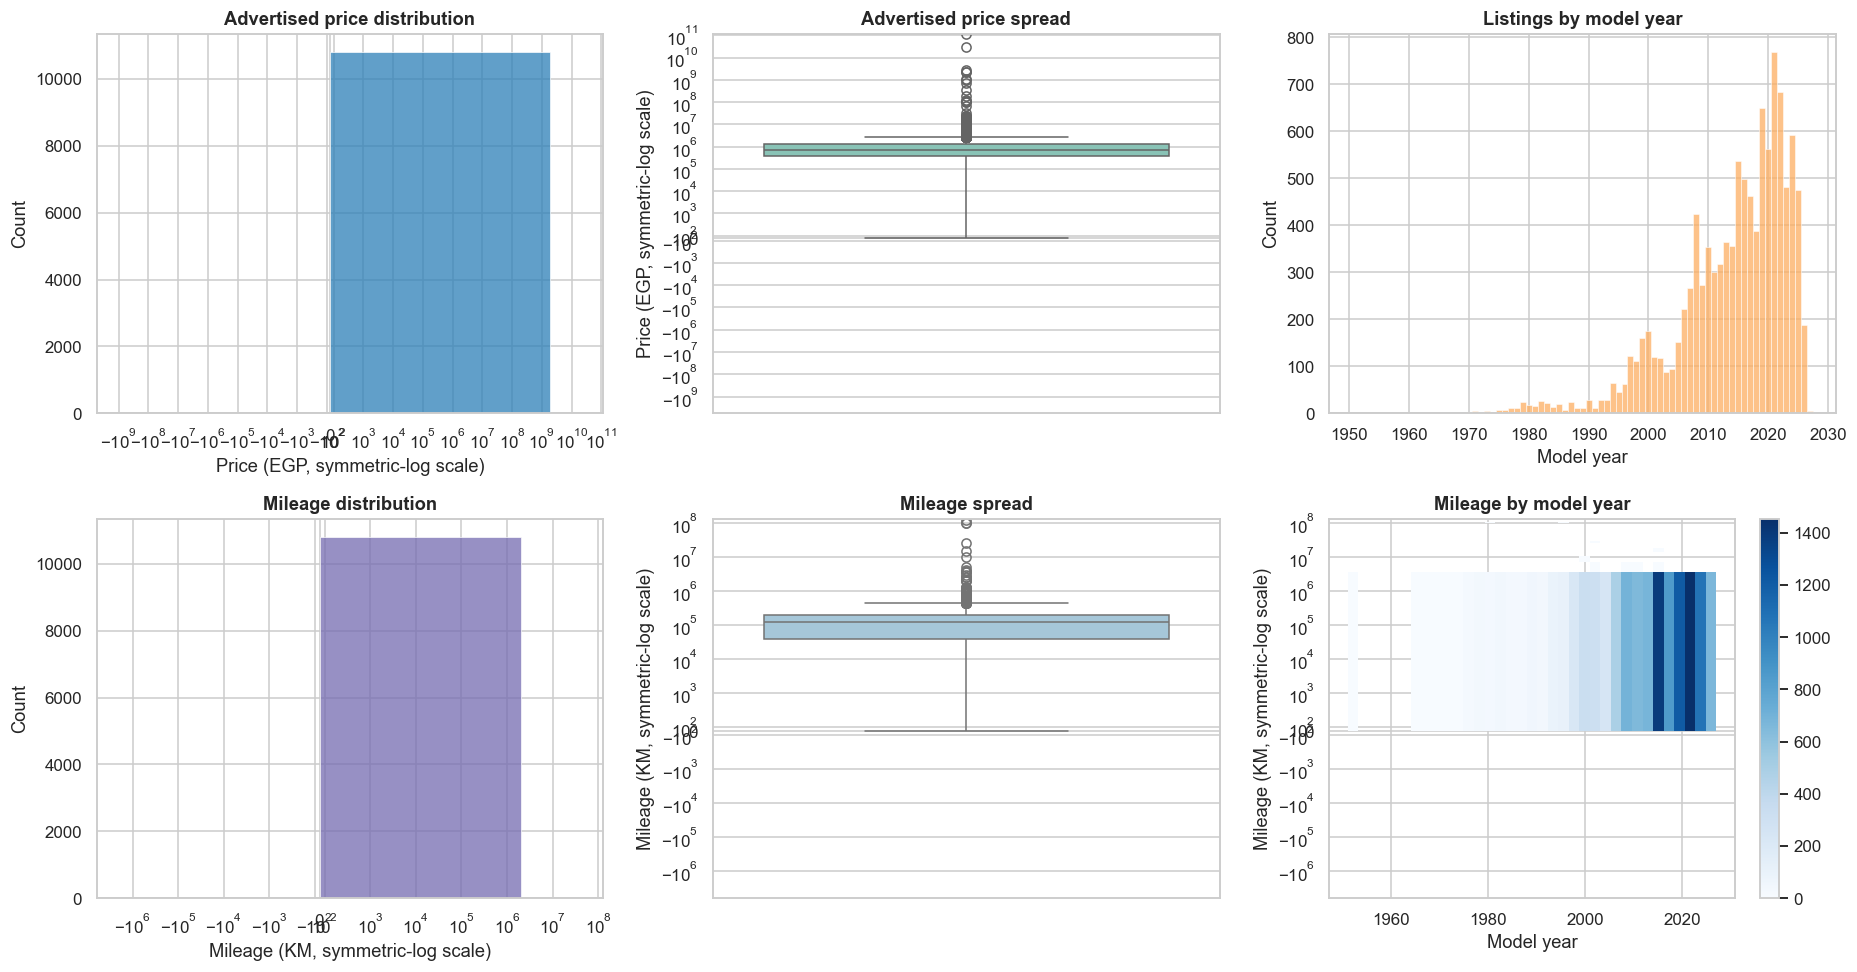

In [8]:
numeric_summary = df_eda[['price', 'year', 'km_numeric']].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T
numeric_summary['median'] = df_eda[['price', 'year', 'km_numeric']].median()
display(numeric_summary.round(2))

fig, axes = plt.subplots(2, 3, figsize=(17, 9))

sns.histplot(data=df_eda, x='price', bins=60, ax=axes[0, 0], color='#2c7fb8')
axes[0, 0].set_xscale('symlog', linthresh=1_000)
axes[0, 0].set_title('Advertised price distribution')
axes[0, 0].set_xlabel('Price (EGP, symmetric-log scale)')

sns.boxplot(y=df_eda['price'], ax=axes[0, 1], color='#7fcdbb')
axes[0, 1].set_yscale('symlog', linthresh=1_000)
axes[0, 1].set_title('Advertised price spread')
axes[0, 1].set_ylabel('Price (EGP, symmetric-log scale)')

sns.histplot(data=df_eda, x='year', discrete=True, ax=axes[0, 2], color='#fdae61')
axes[0, 2].set_title('Listings by model year')
axes[0, 2].set_xlabel('Model year')

sns.histplot(data=df_eda, x='km_numeric', bins=60, ax=axes[1, 0], color='#756bb1')
axes[1, 0].set_xscale('symlog', linthresh=1_000)
axes[1, 0].set_title('Mileage distribution')
axes[1, 0].set_xlabel('Mileage (KM, symmetric-log scale)')

sns.boxplot(y=df_eda['km_numeric'], ax=axes[1, 1], color='#9ecae1')
axes[1, 1].set_yscale('symlog', linthresh=1_000)
axes[1, 1].set_title('Mileage spread')
axes[1, 1].set_ylabel('Mileage (KM, symmetric-log scale)')

sns.histplot(data=df_eda, x='year', y='km_numeric', bins=35, cbar=True, ax=axes[1, 2], cmap='Blues')
axes[1, 2].set_yscale('symlog', linthresh=1_000)
axes[1, 2].set_title('Mileage by model year')
axes[1, 2].set_xlabel('Model year')
axes[1, 2].set_ylabel('Mileage (KM, symmetric-log scale)')

plt.tight_layout()
plt.show()

## Market composition

Brand, model, and location have many categories. The following charts show only the most frequent categories and label the limit explicitly, less frequent categories remain present in the underlying data.

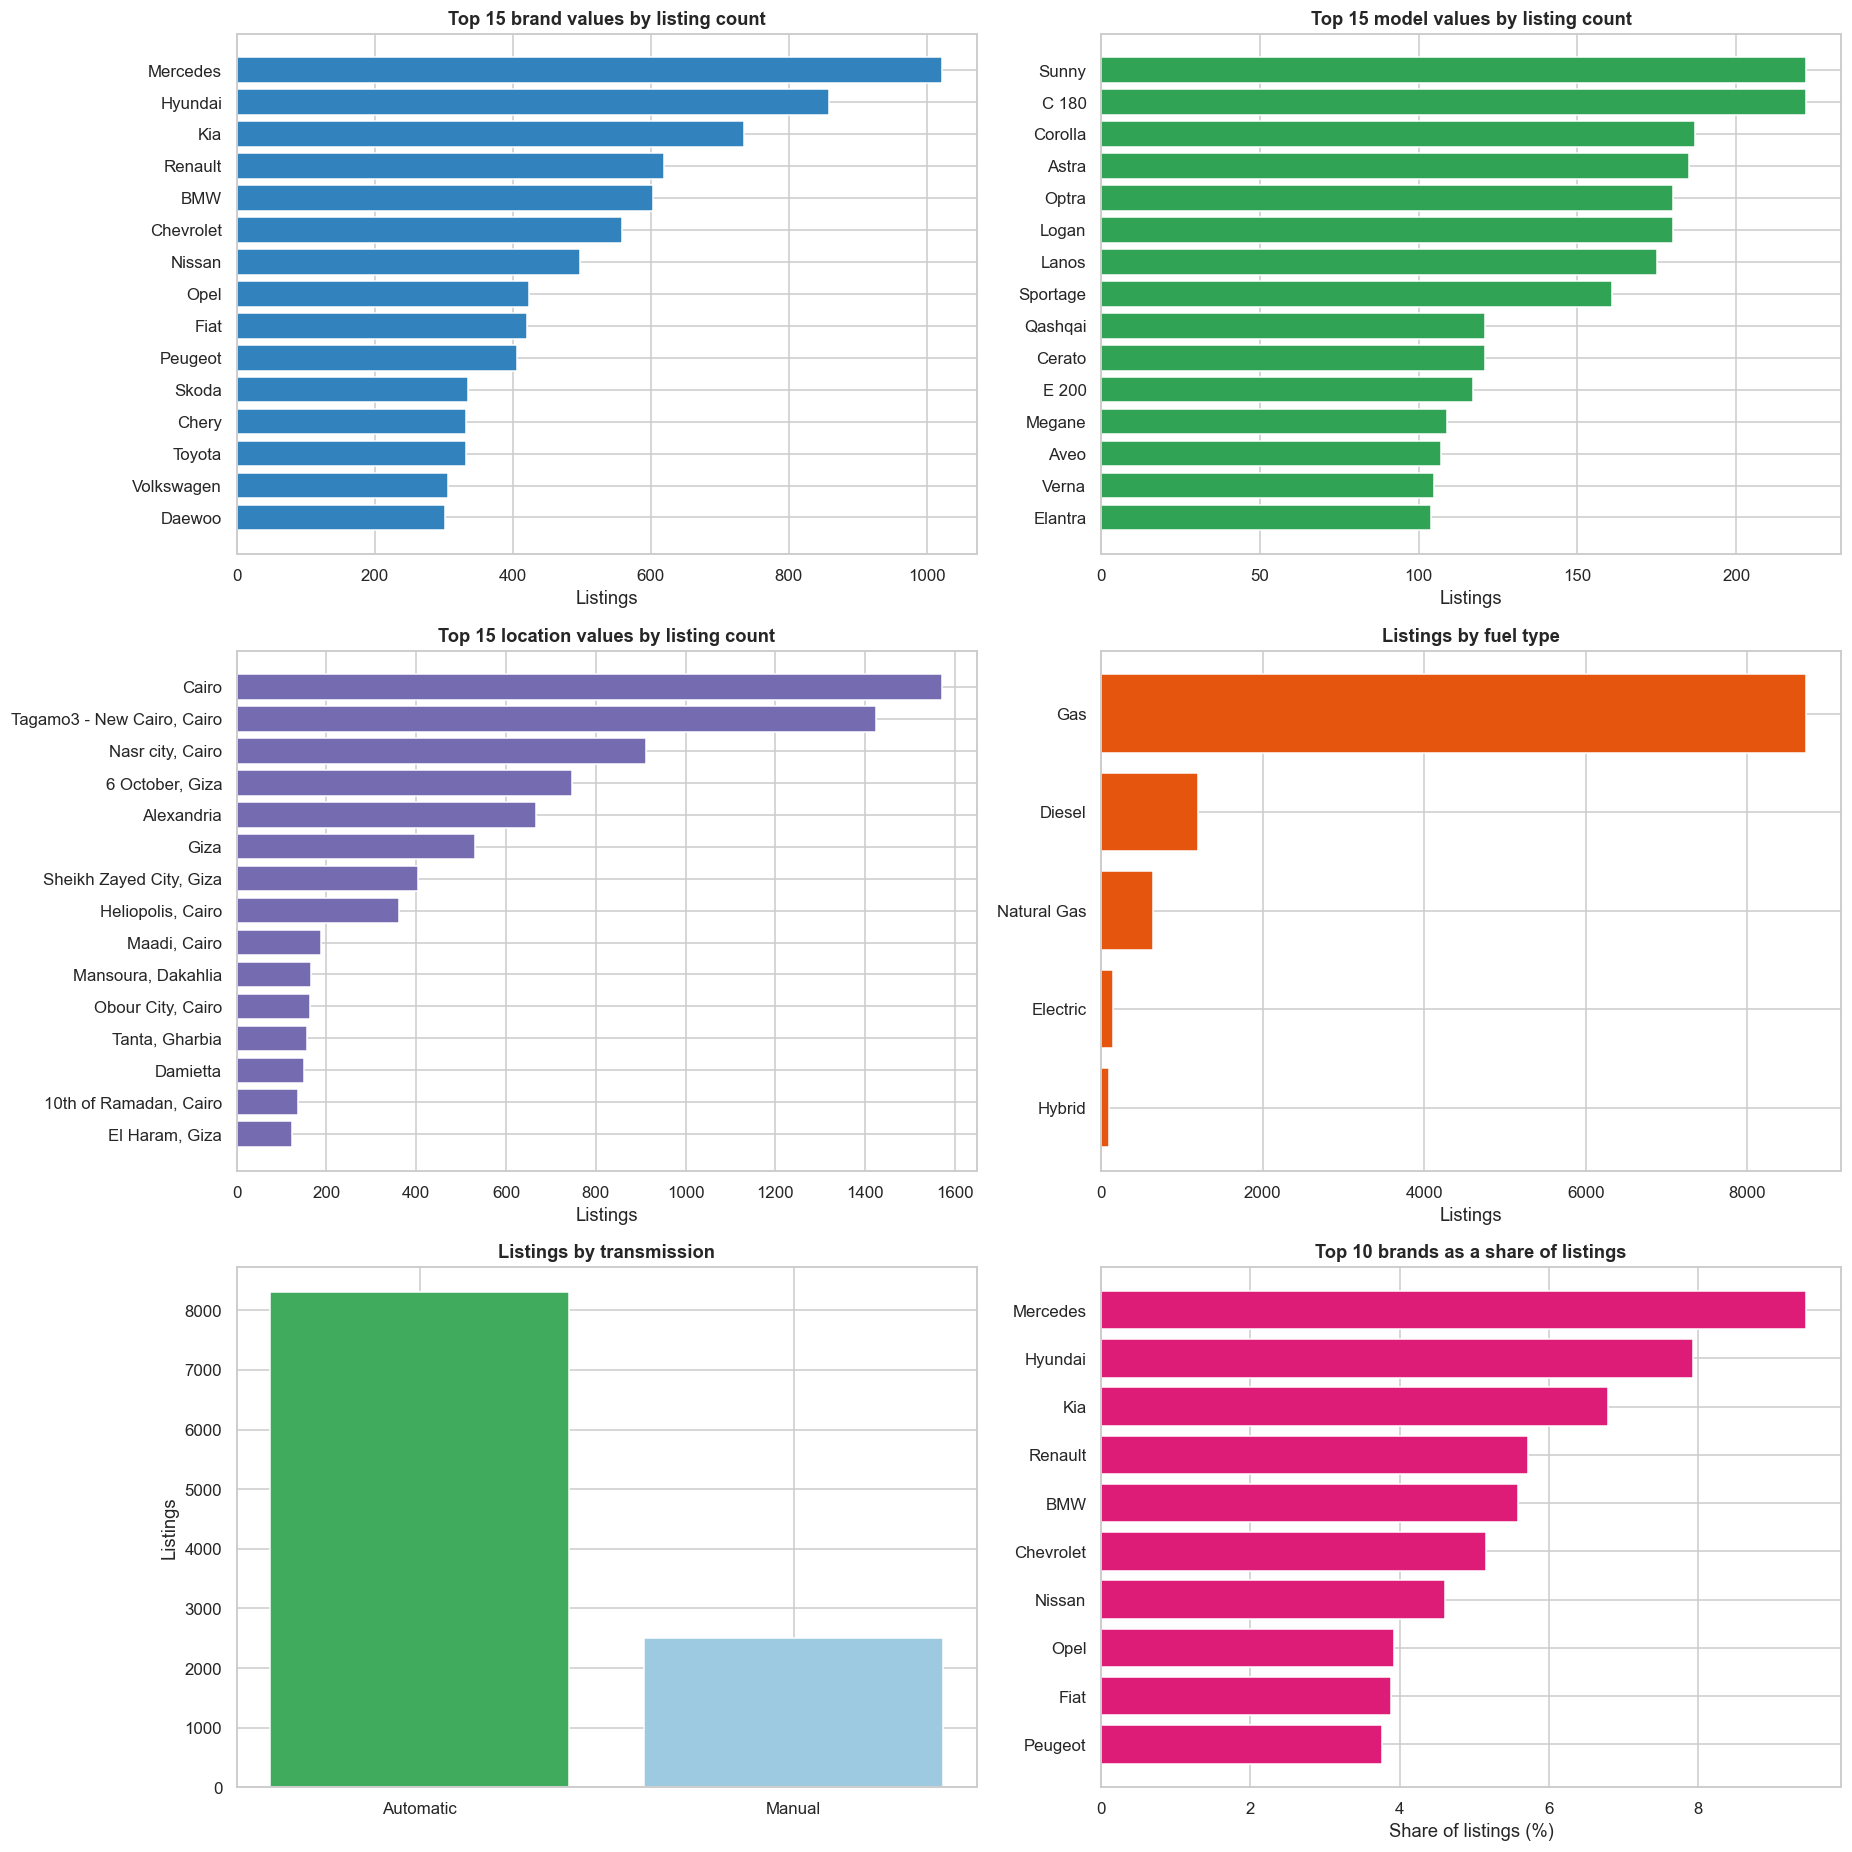

In [9]:
def top_counts(frame: pd.DataFrame, column: str, n: int = 15) -> pd.DataFrame:
    return frame[column].value_counts().head(n).sort_values()

fig, axes = plt.subplots(3, 2, figsize=(17, 17))

for ax, column, label, color in [
    (axes[0, 0], 'brand', 'Brand', '#3182bd'),
    (axes[0, 1], 'model', 'Model', '#31a354'),
    (axes[1, 0], 'city', 'Location', '#756bb1'),
]:
    counts = top_counts(df_eda, column)
    ax.barh(counts.index, counts.values, color=color)
    ax.set_title(f'Top 15 {label.lower()} values by listing count')
    ax.set_xlabel('Listings')

fuel_counts = df_eda['fuel_display'].value_counts().sort_values()
axes[1, 1].barh(fuel_counts.index, fuel_counts.values, color='#e6550d')
axes[1, 1].set_title('Listings by fuel type')
axes[1, 1].set_xlabel('Listings')

transmission_counts = df_eda['transmission_label'].value_counts().reindex(['Automatic', 'Manual', 'Unknown']).dropna()
axes[2, 0].bar(transmission_counts.index, transmission_counts.values, color=['#41ab5d', '#9ecae1', '#bdbdbd'])
axes[2, 0].set_title('Listings by transmission')
axes[2, 0].set_ylabel('Listings')

brand_share = df_eda['brand'].value_counts(normalize=True).head(10).mul(100).sort_values()
axes[2, 1].barh(brand_share.index, brand_share.values, color='#dd1c77')
axes[2, 1].set_title('Top 10 brands as a share of listings')
axes[2, 1].set_xlabel('Share of listings (%)')

plt.tight_layout()
plt.show()

## Price relationships and potential predictive signals

The following comparisons are descriptive associations, not causal effects. Logarithmic price axes make the dominant price range readable; the zero-price listing is omitted only from those specific log-price plots.

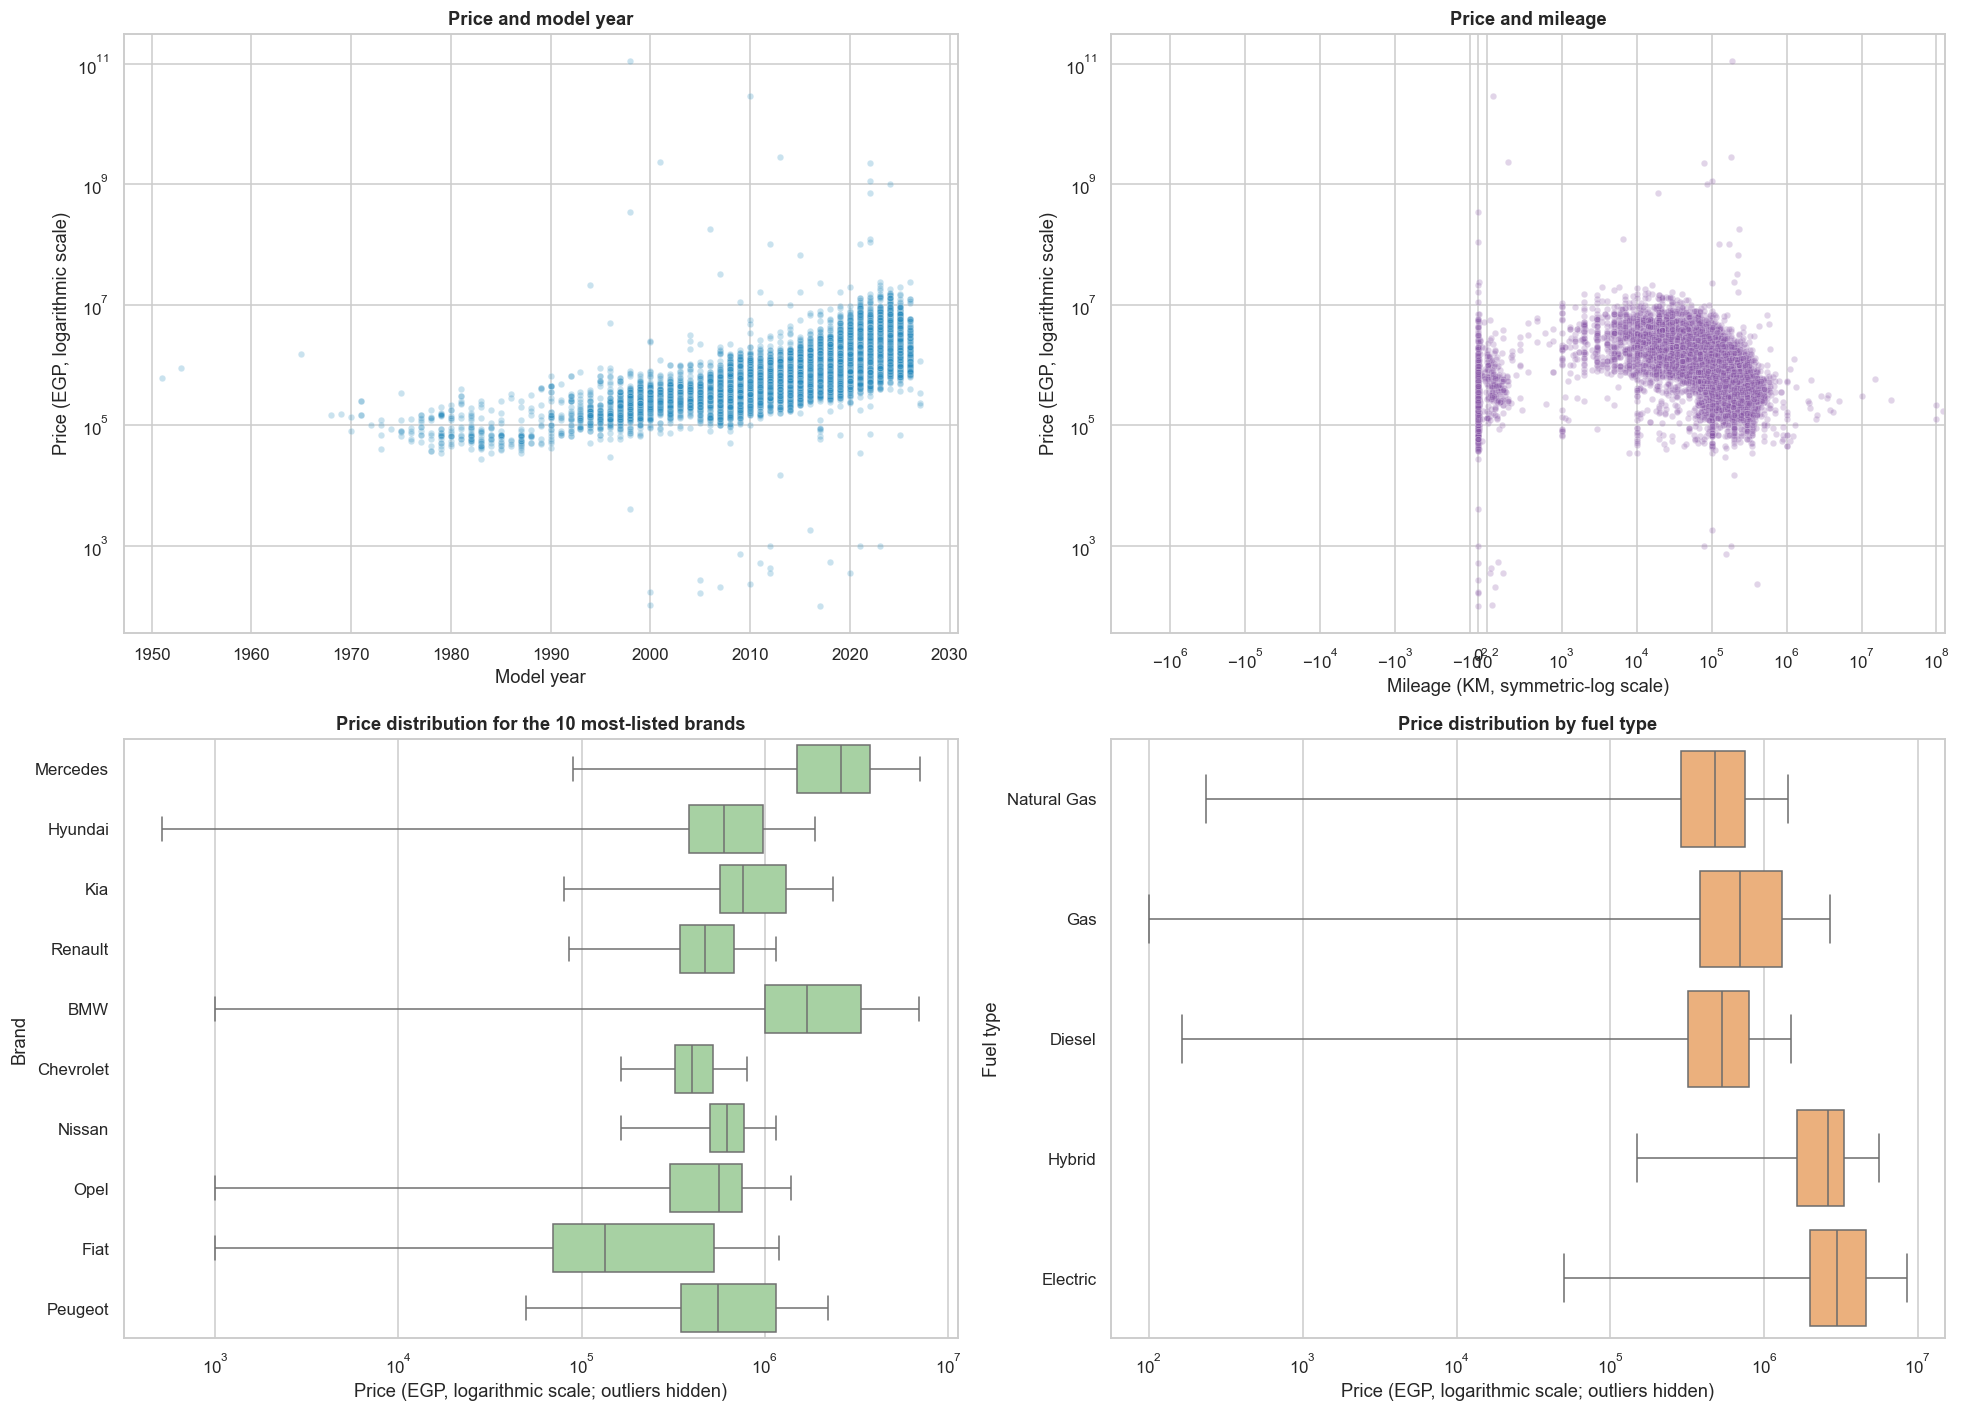

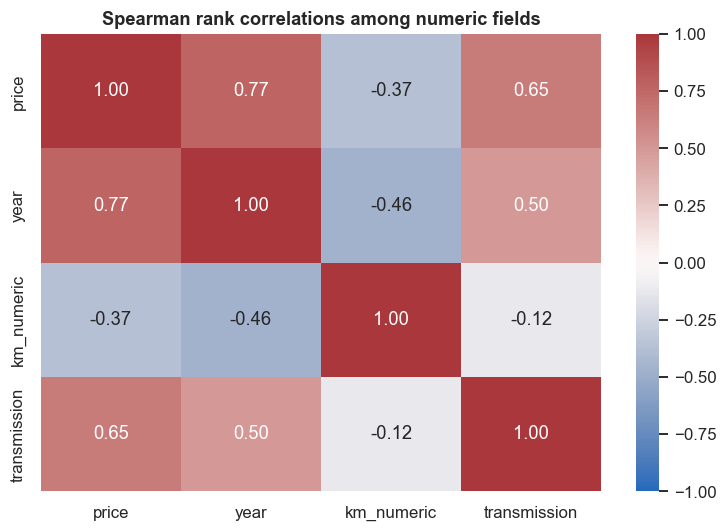

,Median price (EGP)
transmission_label,
Manual,250000.0
Automatic,840000.0


In [10]:
positive_price = df_eda[df_eda['price'] > 0].copy()
top_brands = df_eda['brand'].value_counts().head(10).index
top_brand_prices = positive_price[positive_price['brand'].isin(top_brands)]

fig, axes = plt.subplots(2, 2, figsize=(18, 13))

sns.scatterplot(data=positive_price, x='year', y='price', alpha=0.25, s=18, ax=axes[0, 0], color='#2b8cbe')
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('Price and model year')
axes[0, 0].set_xlabel('Model year')
axes[0, 0].set_ylabel('Price (EGP, logarithmic scale)')

sns.scatterplot(data=positive_price, x='km_numeric', y='price', alpha=0.25, s=18, ax=axes[0, 1], color='#8856a7')
axes[0, 1].set_xscale('symlog', linthresh=1_000)
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('Price and mileage')
axes[0, 1].set_xlabel('Mileage (KM, symmetric-log scale)')
axes[0, 1].set_ylabel('Price (EGP, logarithmic scale)')

sns.boxplot(data=top_brand_prices, x='price', y='brand', order=top_brands, ax=axes[1, 0], color='#a1d99b', showfliers=False)
axes[1, 0].set_xscale('log')
axes[1, 0].set_title('Price distribution for the 10 most-listed brands')
axes[1, 0].set_xlabel('Price (EGP, logarithmic scale; outliers hidden)')
axes[1, 0].set_ylabel('Brand')

sns.boxplot(data=positive_price, x='price', y='fuel_display', ax=axes[1, 1], color='#fdae6b', showfliers=False)
axes[1, 1].set_xscale('log')
axes[1, 1].set_title('Price distribution by fuel type')
axes[1, 1].set_xlabel('Price (EGP, logarithmic scale; outliers hidden)')
axes[1, 1].set_ylabel('Fuel type')

plt.tight_layout()
plt.show()

correlation_columns = ['price', 'year', 'km_numeric', 'transmission']
spearman_corr = df_eda[correlation_columns].corr(method='spearman')
plt.figure(figsize=(7, 5))
sns.heatmap(spearman_corr, annot=True, fmt='.2f', cmap='vlag', center=0, vmin=-1, vmax=1)
plt.title('Spearman rank correlations among numeric fields')
plt.tight_layout()
plt.show()

median_price_by_transmission = positive_price.groupby('transmission_label')['price'].median().sort_values()
display(median_price_by_transmission.rename('Median price (EGP)').to_frame())

## Findings and next steps



In [11]:
top_brand = df_eda['brand'].value_counts().idxmax()
top_brand_count = int(df_eda['brand'].value_counts().max())
median_price = df_eda['price'].median()
price_p99 = df_eda['price'].quantile(0.99)
year_price_corr = spearman_corr.loc['year', 'price']
km_price_corr = spearman_corr.loc['km_numeric', 'price']
empty_columns = ', '.join(profile.index[profile['missing_%'].eq(100)].tolist())

display(Markdown(f'''### Key observations

- The dataset contains **{len(df_eda):,} raw listings** and **{df_eda['id'].nunique():,} unique listing IDs**. `{top_brand}` is the most common brand, with {top_brand_count:,} listings.
- Advertised price is strongly right-skewed: the median is **{median_price:,.0f} EGP**, while the 99th percentile is **{price_p99:,.0f} EGP**. Means should therefore be interpreted carefully.
- In this sample, price has a positive Spearman association with model year ({year_price_corr:.2f}) and a negative association with recorded mileage ({km_price_corr:.2f}). These are associations, not causal estimates.
- Brand, model, location, fuel type, transmission, year, and mileage are plausible future model inputs. `id` and `fingerprint` should remain identifiers rather than predictive features.

### Deferred to preprocessing

- Resolve the all-missing fields: **{empty_columns}**.
- Decide how to treat zero values, extreme prices and mileages, future model years, and inconsistent categorical labels.
- Convert selected fields, encode categories, scale features when required by the chosen model, and construct train/validation/test splits without leakage.
'''))

### Key observations

- The dataset contains **10,819 raw listings** and **10,819 unique listing IDs**. `Mercedes` is the most common brand, with 1,022 listings.
- Advertised price is strongly right-skewed: the median is **670,000 EGP**, while the 99th percentile is **8,750,000 EGP**. Means should therefore be interpreted carefully.
- In this sample, price has a positive Spearman association with model year (0.77) and a negative association with recorded mileage (-0.37). These are associations, not causal estimates.
- Brand, model, location, fuel type, transmission, year, and mileage are plausible future model inputs. `id` and `fingerprint` should remain identifiers rather than predictive features.

### Deferred to preprocessing

- Resolve the all-missing fields: **ad_date, color, class**.
- Decide how to treat zero values, extreme prices and mileages, future model years, and inconsistent categorical labels.
- Convert selected fields, encode categories, scale features when required by the chosen model, and construct train/validation/test splits without leakage.
